# PINN-3 v1 — Energy / Penman PINN  (10-day dataset)

**Caspian Sea — DAHITI water level   ·   ERA5 / GLDAS forcings   ·   Volga discharge**

Third frequency variant of the same v1 PINN-3 model (alongside monthly and daily).
The architecture, physics, hyperparameters and split are identical to the monthly
notebook — only the data file and a couple of training-loop constants change so
the model sees data on a 10-day cadence (~36 steps/year).

Dataset: `merged_grid_dataset_10day.nc` (1 193 time steps, 1993–2026).


## 1.  Imports and configuration

In [1]:
import os
import json
import copy
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt

# Drop pinn3_energy.py next to this notebook (same file as monthly version)
from pinn3_energy import EnergyPINN3


In [2]:
# ── Configuration ────────────────────────────────────────────────────────
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_END_YEAR = 2017
BATCH_SIZE     = 32
LR             = 3e-4
EPOCHS         = 150          # 10-day cadence → fewer epochs needed than monthly
SEQ_LEN        = 12           # ~4 months of look-back
LAMBDA_PHYS    = 1.0
PATIENCE       = 30

VERSION = "v1_10day"
OUT_DIR = f"results/pinn3/{VERSION}"
os.makedirs(OUT_DIR, exist_ok=True)

DATA_PATH  = "merged_grid_dataset_10day.nc"
VOLGA_PATH = "volga_discharge.csv"

print(f"Device: {DEVICE} | Version: {VERSION} | SeqLen: {SEQ_LEN}")


Device: cpu | Version: v1_10day | SeqLen: 12


## 2.  Data loading

`lsm` is inside `merged_grid_dataset_10day.nc` — no separate file needed.


In [3]:
ds = xr.open_dataset(DATA_PATH)
print("Variables :", list(ds.data_vars))
print("Time range:", str(ds.time.values[0])[:10], "→", str(ds.time.values[-1])[:10])
print("Time steps:", len(ds.time))

volga_df         = pd.read_csv(VOLGA_PATH)
volga_df['time'] = pd.to_datetime(volga_df['time'])
volga_df         = volga_df.set_index('time').sort_index()

# Land-sea mask from same NetCDF
lsm_raw = ds.lsm.values
if lsm_raw.ndim == 3: lsm_raw = lsm_raw[0]
basin_mask = lsm_raw >  0.5
lake_mask  = lsm_raw <= 0.5
print(f"Grid: {basin_mask.shape}   basin={basin_mask.sum()}   lake={lake_mask.sum()}")


Variables : ['u10', 'v10', 'd2m', 't2m', 'snowc', 'sde', 'sd', 'sp', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'tp', 'e', 'ssr', 'str', 'Qs_acc', 'Qsb_acc', 'SWE_inst', 'water_level', 'delta_water_level', 'lsm']
Time range: 1993-01-01 → 2026-02-11
Time steps: 1193
Grid: (110, 90)   basin=5506   lake=4394


## 3.  Basin- and lake-averaged forcings

Values are **per 10-day step** — about 3× smaller than monthly because each
step covers ~3× less time.


In [4]:
def basin_avg(field, mask):
    return field.where(mask).mean(dim=['latitude', 'longitude']).to_series().fillna(0)

# Basin
P_basin   = basin_avg(ds.tp, basin_mask)
PET_basin = (basin_avg(ds.ssr, basin_mask) / 2.5e9).clip(lower=1e-5)

# Lake observed
P_lake = basin_avg(ds.tp,  lake_mask)
E_lake = basin_avg(-ds.e,  lake_mask)

# Penman drivers
T_lake_C   = basin_avg(ds.t2m, lake_mask) - 273.15
Td_lake_C  = basin_avg(ds.d2m, lake_mask) - 273.15
Rn_lake_eq = (basin_avg(ds.ssr, lake_mask) + basin_avg(ds.str, lake_mask)) / 2.5e9
U_lake     = np.sqrt(basin_avg(ds.u10, lake_mask)**2 + basin_avg(ds.v10, lake_mask)**2)
P_kpa_lake = basin_avg(ds.sp, lake_mask) / 1000.0

# Target — use the dataset's own delta_water_level
water_level = ds.water_level.to_series().ffill().fillna(0)
if 'delta_water_level' in ds.data_vars:
    delta_h = ds.delta_water_level.to_series().fillna(0)
    print("Target source: ds.delta_water_level")
else:
    delta_h = water_level.diff().fillna(0)
    print("Target source: water_level.diff()")

print(f"P_basin   mean = {P_basin.mean():.6f} m/10day")
print(f"PET_basin mean = {PET_basin.mean():.6f} m/10day")
print(f"P_lake    mean = {P_lake.mean():.6f} m/10day")
print(f"E_lake    mean = {E_lake.mean():.6f} m/10day")
print(f"T_lake    mean = {T_lake_C.mean():.2f} °C   ← must be ~12-14 °C")
print(f"U_lake    mean = {U_lake.mean():.2f} m/s")
print(f"Δh        mean = {delta_h.mean():.7f}  std = {delta_h.std():.7f}")


Target source: ds.delta_water_level
P_basin   mean = 0.012578 m/10day
PET_basin mean = 0.049518 m/10day
P_lake    mean = 0.008521 m/10day
E_lake    mean = 0.028386 m/10day
T_lake    mean = 14.91 °C   ← must be ~12-14 °C
U_lake    mean = 2.28 m/s
Δh        mean = -0.0017734  std = 0.0554804


## 4.  Dataset class

In [5]:
class EnergyDataset(Dataset):
    GRID_VARS = ['tp', 't2m', 'ssr', 'str', 'sp', 'e', 'd2m',
                 'u10', 'v10', 'Qs_acc', 'Qsb_acc', 'SWE_inst']

    def __init__(self, ds, volga_df, seq_len=12, stats=None):
        self.times   = ds.time.values
        self.seq_len = seq_len

        # 12 ERA5/GLDAS channels + Volga broadcast = 13 channels
        data_list = [ds[v].values for v in self.GRID_VARS]
        volga_grid = []
        for t in ds.time.values:
            t_dt = pd.to_datetime(t)
            try:
                idx = volga_df.index.get_indexer([t_dt], method='nearest')[0]
                q   = float(volga_df.iloc[idx]['volga_q'])
            except Exception:
                q = 8000.0
            volga_grid.append(np.full_like(data_list[0][0], q, dtype=np.float32))
        data_list.append(np.array(volga_grid, dtype=np.float32))
        self.data = np.stack(data_list, axis=1).astype(np.float32)

        self.targets   = delta_h.values.astype(np.float32)
        self.p_basin   = P_basin.values.astype(np.float32)
        self.pet_basin = PET_basin.values.astype(np.float32)
        self.p_lake    = P_lake.values.astype(np.float32)
        self.e_lake    = E_lake.values.astype(np.float32)
        self.T_lake    = T_lake_C.values.astype(np.float32)
        self.Td_lake   = Td_lake_C.values.astype(np.float32)
        self.Rn_lake   = Rn_lake_eq.values.astype(np.float32)
        self.U_lake    = U_lake.values.astype(np.float32)
        self.P_kpa     = P_kpa_lake.values.astype(np.float32)

        if stats is None:
            self.stats = {
                'mean': np.nanmean(self.data, axis=(0, 2, 3), keepdims=True),
                'std':  np.nanstd (self.data, axis=(0, 2, 3), keepdims=True),
            }
            self.target_mean = float(np.mean(self.targets))
            self.target_std  = float(np.std(self.targets))
        else:
            self.stats       = stats
            self.target_mean = stats['target_mean']
            self.target_std  = stats['target_std']

        self.data         = np.nan_to_num((self.data - self.stats['mean']) /
                                          (self.stats['std'] + 1e-8))
        self.targets_raw  = self.targets
        self.targets_norm = (self.targets - self.target_mean) / (self.target_std + 1e-8)
        self.valid_indices = [i for i in range(len(self.times)) if i >= seq_len - 1]

    def __len__(self): return len(self.valid_indices)

    def __getitem__(self, idx):
        i = self.valid_indices[idx]
        x = self.data[i - self.seq_len + 1 : i + 1]
        return (
            torch.from_numpy(x),
            torch.FloatTensor([self.targets_norm[i]]),
            torch.FloatTensor([self.targets_raw[i]]),
            torch.FloatTensor([self.p_basin[i]]),
            torch.FloatTensor([self.pet_basin[i]]),
            torch.FloatTensor([self.p_lake[i]]),
            torch.FloatTensor([self.e_lake[i]]),
            torch.FloatTensor([self.T_lake[i]]),
            torch.FloatTensor([self.Td_lake[i]]),
            torch.FloatTensor([self.Rn_lake[i]]),
            torch.FloatTensor([self.U_lake[i]]),
            torch.FloatTensor([self.P_kpa[i]]),
        )


## 5.  Train / test split

In [6]:
all_years = pd.to_datetime(ds.time.values).year
full_ds   = EnergyDataset(ds, volga_df, seq_len=SEQ_LEN)

train_indices = [i for i, v in enumerate(full_ds.valid_indices) if all_years[v] <= TRAIN_END_YEAR]
test_indices  = [i for i, v in enumerate(full_ds.valid_indices) if all_years[v] >  TRAIN_END_YEAR]

train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(Subset(full_ds, test_indices),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_indices)}  ({all_years.min()}–{TRAIN_END_YEAR})")
print(f"Test  samples: {len(test_indices)}   ({TRAIN_END_YEAR+1}–{all_years.max()})")


Train samples: 889  (1993–2017)
Test  samples: 293   (2018–2026)


## 6.  Model, optimiser, scheduler

In [7]:
model     = EnergyPINN3(in_channels=13, seq_len=SEQ_LEN).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"PINN-3 v1 (10-day) parameters: {sum(p.numel() for p in model.parameters()):,}")


PINN-3 v1 (10-day) parameters: 339,012


## 7.  Training loop

In [8]:
print(f"\n== Training PINN-3 v1 ({VERSION}) ==")
history = {'data_loss': [], 'phys_loss': [], 'val_loss': [],
           'alpha_PT': [], 'C_wind': [], 'gamma_runoff': []}

best_val_loss = float('inf'); patience_counter = 0; best_model_state = None
t_mean = full_ds.target_mean
t_std  = full_ds.target_std

for epoch in range(EPOCHS):
    model.train()
    ep_data_raw = ep_phys_raw = ep_a = ep_c = ep_g = 0.0

    for batch in train_loader:
        (x, y_norm, y_raw,
         p_b, pet_b, p_l, e_l,
         T_l, Td_l, Rn_l, U_l, Pk_l) = [b.to(DEVICE) for b in batch]

        optimizer.zero_grad()
        dh_pred_norm, alpha_PT, C_wind, gamma_runoff = model(x)
        dh_pred_raw = dh_pred_norm * t_std + t_mean

        loss_data = F.mse_loss(dh_pred_norm, y_norm)
        loss_phys, _ = model.penman_loss(
            dh_pred_raw, alpha_PT, C_wind, gamma_runoff,
            T_l, Td_l, Rn_l, U_l, Pk_l, p_l, p_b, pet_b,
        )

        total_loss = loss_data + LAMBDA_PHYS * loss_phys
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            data_raw = F.mse_loss(dh_pred_raw, y_raw).item()
        ep_data_raw += data_raw
        ep_phys_raw += loss_phys.item()
        ep_a += alpha_PT.mean().item()
        ep_c += C_wind.mean().item()
        ep_g += gamma_runoff.mean().item()

    scheduler.step()

    model.eval()
    val_l_raw = 0.0
    with torch.no_grad():
        for batch in test_loader:
            x, _, y_raw, *_ = [b.to(DEVICE) for b in batch]
            dh_pred_norm, *_ = model(x)
            dh_pred_raw = dh_pred_norm * t_std + t_mean
            val_l_raw += F.mse_loss(dh_pred_raw, y_raw).item()

    n_b = len(train_loader); n_v = len(test_loader)
    for k, v in zip(
        ['data_loss','phys_loss','val_loss','alpha_PT','C_wind','gamma_runoff'],
        [ep_data_raw/n_b, ep_phys_raw/n_b, val_l_raw/n_v, ep_a/n_b, ep_c/n_b, ep_g/n_b],
    ):
        history[k].append(v)

    avg_val = history['val_loss'][-1]
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Ep {epoch+1:3d}/{EPOCHS} | "
              f"Data(m²): {history['data_loss'][-1]:.7f} | "
              f"Phys(m²): {history['phys_loss'][-1]:.7f} | "
              f"Val(m²): {avg_val:.7f} | "
              f"α_PT={history['alpha_PT'][-1]:.2f}  "
              f"C_w={history['C_wind'][-1]:.2f}  "
              f"γ_r={history['gamma_runoff'][-1]:.2f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)



== Training PINN-3 v1 (v1_10day) ==
Ep  10/150 | Data(m²): 0.0026699 | Phys(m²): 0.0023379 | Val(m²): 0.0021013 | α_PT=1.50  C_w=0.55  γ_r=0.60
Ep  20/150 | Data(m²): 0.0026350 | Phys(m²): 0.0021411 | Val(m²): 0.0020812 | α_PT=1.36  C_w=0.46  γ_r=0.51
Ep  30/150 | Data(m²): 0.0025876 | Phys(m²): 0.0019837 | Val(m²): 0.0020931 | α_PT=1.29  C_w=0.41  γ_r=0.46
Ep  40/150 | Data(m²): 0.0025407 | Phys(m²): 0.0020713 | Val(m²): 0.0020967 | α_PT=1.24  C_w=0.45  γ_r=0.40
Early stopping at epoch 46


## 8.  Loss curves

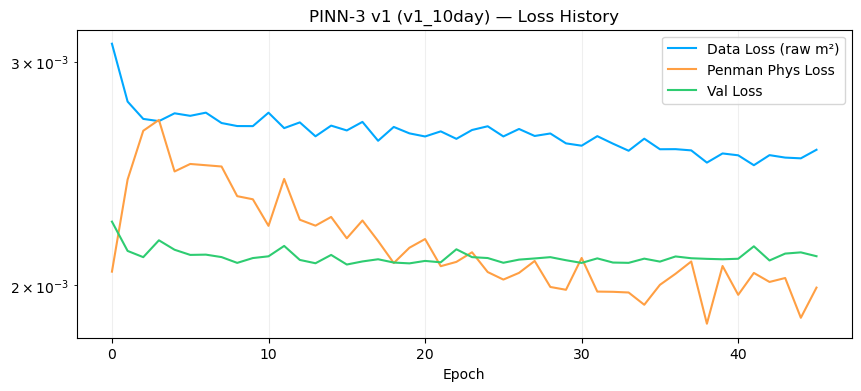

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(history['data_loss'], label='Data Loss (raw m²)', color='#00a8ff')
plt.plot(history['phys_loss'], label='Penman Phys Loss',   color='#ff9f43')
plt.plot(history['val_loss'],  label='Val Loss',           color='#2ecc71')
plt.yscale('log')
plt.title(f"PINN-3 v1 ({VERSION}) — Loss History")
plt.xlabel("Epoch"); plt.legend(); plt.grid(True, alpha=0.2)
plt.savefig(os.path.join(OUT_DIR, 'loss_curves.png'), dpi=130, bbox_inches='tight')
plt.show()


## 9.  Test-set reconstruction

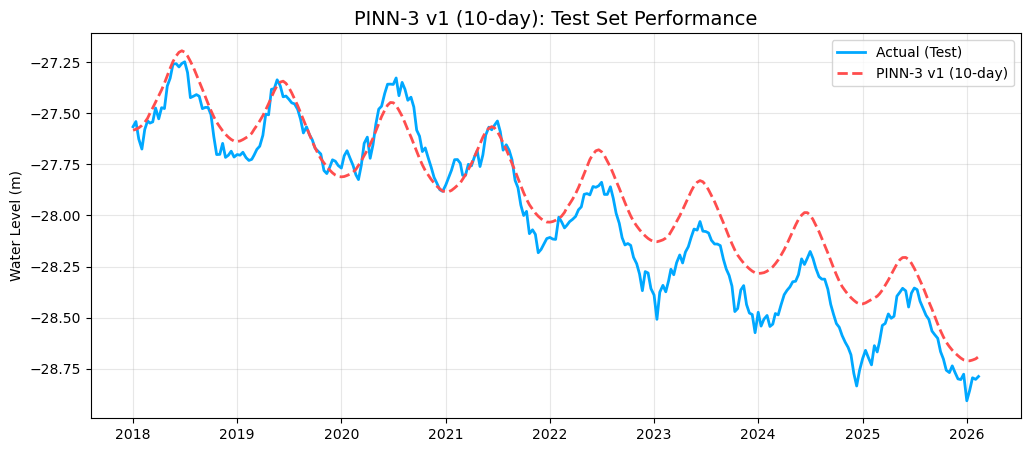

In [10]:
model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        x, _, y_raw, *_ = [b.to(DEVICE) for b in batch]
        p_norm, *_ = model(x)
        p_raw = p_norm * t_std + t_mean
        test_preds  .append(p_raw.cpu().numpy().flatten())
        test_targets.append(y_raw.cpu().numpy().flatten())

p_raw = np.concatenate(test_preds)
t_raw = np.concatenate(test_targets)
test_times = pd.to_datetime([full_ds.times[full_ds.valid_indices[i]] for i in test_indices])

last_train_idx    = train_indices[-1]
start_test_level  = water_level.iloc[full_ds.valid_indices[last_train_idx]]
actual_test_level = start_test_level + np.cumsum(t_raw)
pred_test_level   = start_test_level + np.cumsum(p_raw)

plt.figure(figsize=(12, 5))
plt.plot(test_times, actual_test_level, label='Actual (Test)', color='#00a8ff', linewidth=2)
plt.plot(test_times, pred_test_level,   label='PINN-3 v1 (10-day)',
         color='#ff4d4d', linestyle='--', linewidth=2)
plt.title(f"PINN-3 v1 (10-day): Test Set Performance", fontsize=14)
plt.ylabel("Water Level (m)"); plt.grid(True, alpha=0.3); plt.legend()
plt.savefig(os.path.join(OUT_DIR, 'water_level_test.png'), dpi=130, bbox_inches='tight')
plt.show()


## 10.  Full-period reconstruction

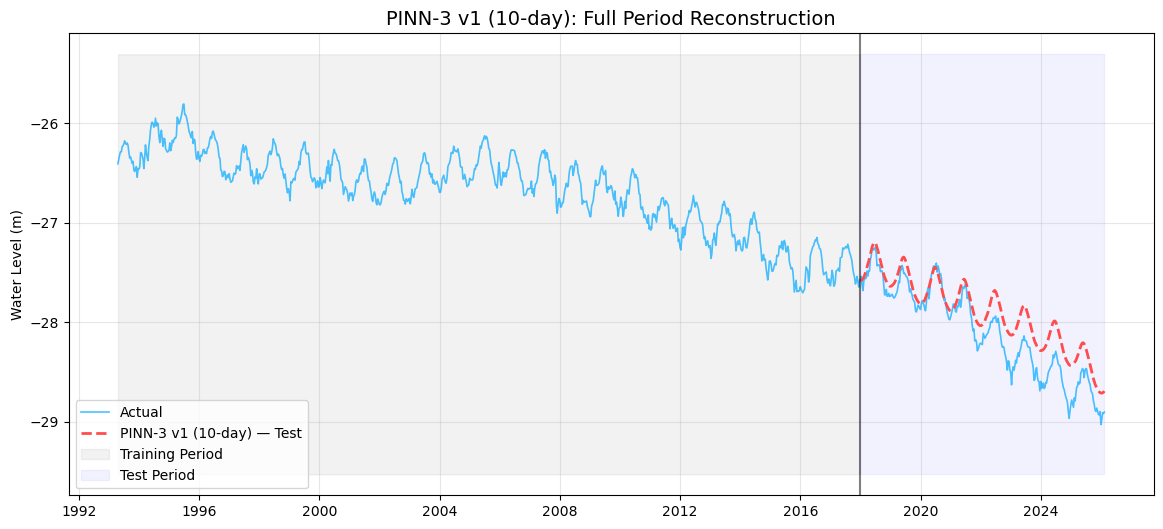

In [11]:
full_times  = pd.to_datetime([full_ds.times[v] for v in full_ds.valid_indices])
full_actual = water_level.iloc[full_ds.valid_indices].values

plt.figure(figsize=(14, 6))
plt.plot(full_times, full_actual, label='Actual', color='#00a8ff', linewidth=1.2, alpha=0.7)
plt.plot(test_times, pred_test_level, label='PINN-3 v1 (10-day) — Test',
         color='#ff4d4d', linestyle='--', linewidth=2)
plt.axvline(test_times[0], color='black', linestyle='-', alpha=0.5)
plt.fill_between(full_times, full_actual.min()-0.5, full_actual.max()+0.5,
                 where=(full_times < test_times[0]),
                 color='gray', alpha=0.1, label='Training Period')
plt.fill_between(test_times, full_actual.min()-0.5, full_actual.max()+0.5,
                 color='blue', alpha=0.05, label='Test Period')
plt.title("PINN-3 v1 (10-day): Full Period Reconstruction", fontsize=14)
plt.ylabel("Water Level (m)"); plt.grid(True, alpha=0.3); plt.legend(loc='lower left')
plt.savefig(os.path.join(OUT_DIR, 'full_period_reconstruction.png'), dpi=130, bbox_inches='tight')
plt.show()


## 11.  Physics-parameter trajectories

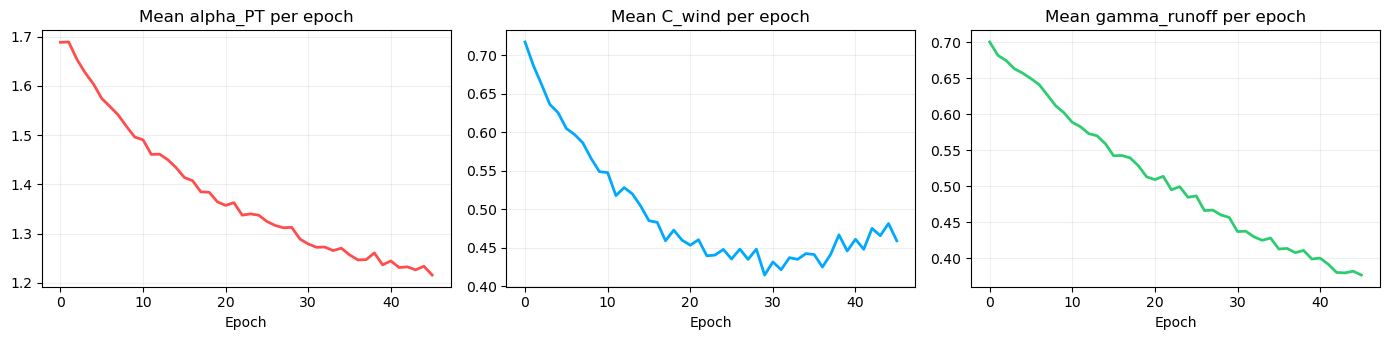

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, key, color in zip(
    axes,
    ['alpha_PT', 'C_wind', 'gamma_runoff'],
    ['#ff4d4d', '#00a8ff', '#2ecc71'],
):
    ax.plot(history[key], color=color, linewidth=2)
    ax.set_title(f"Mean {key} per epoch")
    ax.grid(True, alpha=0.2); ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'physics_params.png'), dpi=130, bbox_inches='tight')
plt.show()


## 12.  Metrics

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

mae  = mean_absolute_error(t_raw, p_raw)
rmse = float(np.sqrt(np.mean((p_raw - t_raw) ** 2)))
r2   = r2_score(t_raw, p_raw)
corr = float(np.corrcoef(p_raw, t_raw)[0, 1])

mae_level  = mean_absolute_error(actual_test_level, pred_test_level)
rmse_level = float(np.sqrt(np.mean((actual_test_level - pred_test_level) ** 2)))
r2_level   = r2_score(actual_test_level, pred_test_level)

metrics = {
    'pinn'            : 'PINN-3 v1 (Energy / Penman) — 10-day',
    'version'         : VERSION,
    'mae_dh_test'     : float(mae),
    'rmse_dh_test'    : rmse,
    'r2_dh_test'      : float(r2),
    'corr_dh_test'    : corr,
    'mae_level_test'  : float(mae_level),
    'rmse_level_test' : rmse_level,
    'r2_level_test'   : float(r2_level),
    'alpha_PT_avg'    : float(history['alpha_PT'][-1]),
    'C_wind_avg'      : float(history['C_wind'][-1]),
    'gamma_runoff_avg': float(history['gamma_runoff'][-1]),
    'stopped_epoch'   : len(history['data_loss']),
}
with open(os.path.join(OUT_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))
torch.save(best_model_state, os.path.join(OUT_DIR, 'best_pinn3_10day.pth'))
print(f"\nModel saved → {OUT_DIR}/best_pinn3_10day.pth")


{
  "pinn": "PINN-3 v1 (Energy / Penman) \u2014 10-day",
  "version": "v1_10day",
  "mae_dh_test": 0.033722590655088425,
  "rmse_dh_test": 0.04313353821635246,
  "r2_dh_test": 0.24958759546279907,
  "corr_dh_test": 0.5003006976480764,
  "mae_level_test": 0.12849697470664978,
  "rmse_level_test": 0.15401488542556763,
  "r2_level_test": 0.8710699081420898,
  "alpha_PT_avg": 1.215490196432386,
  "C_wind_avg": 0.45912490465811323,
  "gamma_runoff_avg": 0.3769639166338103,
  "stopped_epoch": 46
}

Model saved → results/pinn3/v1_10day/best_pinn3_10day.pth
